In [ ]:
!pip install -q "numpy==1.26.4" "pandas==2.2.2" "concrete-ml" "scikit-learn==1.5.0" "xgboost==1.6.2" matplotlib

In [ ]:
import os
os._exit(0)

In [3]:
import sys
import numpy
import pandas
import sklearn
import xgboost
import concrete.ml

print("Python:", sys.version)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("concrete-ml:", concrete.ml.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
numpy: 1.26.4
pandas: 2.2.2
sklearn: 1.5.0
xgboost: 1.6.2
concrete-ml: 1.9.0


In [2]:
import concrete.ml

print("concrete-ml:", concrete.ml.__version__)

concrete-ml: 1.9.0


In [3]:
from concrete.ml.sklearn import (
    DecisionTreeClassifier,
    RandomForestClassifier,
    XGBClassifier,
)

print("Concrete-ML imports: OK")

Concrete-ML imports: OK


In [6]:
import os

RESULTS_DIR = '/kaggle/working/FHE_Results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results directory: {RESULTS_DIR}")

Results directory: /kaggle/working/FHE_Results


In [7]:
# FHE CHECKPOINT SYSTEM

import os
import pickle

RESULTS_DIR = "/kaggle/working/FHE_Results"

checkpoint_dir = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_file = os.path.join(
    checkpoint_dir,
    "fhe_results.pkl"
)

print("Checkpoint system ready")
print(f"Checkpoint directory : {checkpoint_dir}")
print(f"Checkpoint file      : {checkpoint_file}")

Checkpoint system ready
Checkpoint directory : /kaggle/working/FHE_Results/checkpoints
Checkpoint file      : /kaggle/working/FHE_Results/checkpoints/fhe_results.pkl


In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from concrete.ml.sklearn import XGBClassifier as ConcreteXGBClassifier

# 1. Load and split dataset
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Classic XGBoost training
model_classic = XGBClassifier(n_estimators=10, max_depth=3, random_state=42)
model_classic.fit(X_train, y_train)
preds_classic = model_classic.predict(X_test)
print(f"Classic XGBoost Accuracy: {accuracy_score(y_test, preds_classic):.4f}")

# 3. FHE XGBoost training (Concrete-ML)
model_fhe = ConcreteXGBClassifier(n_estimators=10, max_depth=3, n_bits=6, random_state=42)
model_fhe.fit(X_train, y_train)

# Compile model into FHE circuits
model_fhe.compile(X_train)

# 4. FHE inference using Concrete-ML 1.9.0
sample = X_test[:1]

# Option A: FHE simulation (Fast, for testing)
pred_sim = model_fhe.predict(sample, fhe="simulate")
print(f"Prediction (FHE Simulation): {pred_sim[0]}")

# Option B: Real encrypted FHE execution (Generates keys & performs actual encryption)
pred_fhe = model_fhe.predict(sample, fhe="execute")
print(f"Prediction (Encrypted FHE) : {pred_fhe[0]}")
print(f"Ground Truth Value         : {y_test[0]}")

Classic XGBoost Accuracy: 0.9561
Prediction (FHE Simulation): 1
Prediction (Encrypted FHE) : 1
Ground Truth Value         : 1


In [10]:
# CELL 2: Load datasets

RANDOM_STATE = 42

from sklearn.datasets import load_breast_cancer, fetch_openml
from sklearn.preprocessing import LabelEncoder

# Dataset 1: WDBC
wdbc = load_breast_cancer()
X_wdbc = wdbc.data
y_wdbc = wdbc.target
print(f"WDBC: {X_wdbc.shape}")

# Dataset 2: Spambase (for direct comparison with Frery et al.)
spam = fetch_openml(name='spambase', version=1, as_frame=True)
X_spam = spam.data.values.astype(float)
if spam.target.dtype == object or str(spam.target.dtype).startswith('category'):
    y_spam = LabelEncoder().fit_transform(spam.target.astype(str))
else:
    y_spam = spam.target.astype(int).values
print(f"Spambase: {X_spam.shape}")

# Dataset 3: Adult / Census Income (mixed numerical/categorical features)
adult = fetch_openml(name='adult', version=2, as_frame=True)
X_adult_raw = adult.data.copy()
y_adult = (adult.target.astype(str).str.strip() == '>50K').astype(int).values
cat_cols_adult = X_adult_raw.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_adult:
    X_adult_raw[col] = LabelEncoder().fit_transform(X_adult_raw[col].astype(str))
X_adult = X_adult_raw.fillna(-1).astype(float).values
print(f"Adult: {X_adult.shape} ({len(cat_cols_adult)} categorical columns label-encoded)")

# Dataset 4: Pima Diabetes
url = ("https://raw.githubusercontent.com/"
       "jbrownlee/Datasets/master/"
       "pima-indians-diabetes.data.csv")
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima = pd.read_csv(url, names=cols)
X_pima = pima.drop('Outcome', axis=1).values
y_pima = pima['Outcome'].values
print(f"Pima: {X_pima.shape}")

# Dataset 5: Heart Disease (UCI Cleveland)
url2 = ("https://archive.ics.uci.edu/ml/"
        "machine-learning-databases/"
        "heart-disease/processed.cleveland.data")
heart = pd.read_csv(url2, header=None, na_values='?')
heart = heart.dropna()
X_heart = heart.iloc[:, :-1].values.astype(float)
y_heart = (heart.iloc[:, -1].values > 0).astype(int)
print(f"Heart Disease: {X_heart.shape}")

datasets = {
    'Spambase': (X_spam, y_spam),
    'WDBC': (X_wdbc, y_wdbc),
    'Adult': (X_adult, y_adult),
    'Pima': (X_pima, y_pima),
    'Heart': (X_heart, y_heart),
}
print("\nAll 5 datasets loaded successfully "
      "(matches Chapter 4 §4.6.1: Spambase, WDBC, Adult, Pima, Heart).")


WDBC: (569, 30)
Spambase: (4601, 57)
Adult: (48842, 14) (8 categorical columns label-encoded)
Pima: (768, 8)
Heart Disease: (297, 13)

All 5 datasets loaded successfully (matches Chapter 4 §4.6.1: Spambase, WDBC, Adult, Pima, Heart).


In [20]:
import platform
import sys
import numpy as np
import pandas as pd
import sklearn
import xgboost
import concrete.ml

try:
    import concrete.fhe as cfhe
    concrete_python_version = getattr(cfhe, "__version__", "unknown")
except Exception:
    concrete_python_version = "unknown"

ENV_INFO = {
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "concrete_ml_version": concrete.ml.__version__,
    "concrete_python_version": concrete_python_version,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
}

print("Environment / software versions (record verbatim in Appendix A):")
for k, v in ENV_INFO.items():
    print(f"  {k}: {v}")

print(
    "\nHardware information for this Kaggle benchmarking session:"
)

!cat /proc/cpuinfo | grep "model name" | head -1
!free -h | grep Mem
!nproc

Environment / software versions (record verbatim in Appendix A):
  python_version: 3.12.13
  platform: Linux-6.12.90+-x86_64-with-glibc2.35
  concrete_ml_version: 1.9.0
  concrete_python_version: 2.10.0
  numpy_version: 1.26.4
  pandas_version: 2.2.2
  sklearn_version: 1.5.0
  xgboost_version: 1.6.2

Hardware information for this Kaggle benchmarking session:
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
Mem:            31Gi       2.2Gi        22Gi       1.0Mi       6.3Gi        28Gi
4


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time
import pandas as pd
import numpy as np
import resource
from datetime import datetime


In [22]:
#CELL 3: Plaintext Experiments (baseline) — with repeated latency timing
N_LATENCY_REPEATS_PLAIN = 10

results = []

for ds_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    models = {
        'DT': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
        'RF': RandomForestClassifier(
            n_estimators=50, max_depth=5, random_state=RANDOM_STATE),
        'XGB': XGBClassifier(
            n_estimators=50, max_depth=5, random_state=RANDOM_STATE,
            eval_metric='logloss', verbosity=0),
    }

    for model_name, model in models.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        # Warm-up call, then repeated timing
        y_pred = model.predict(X_test)
        inf_times = []
        for _rep in range(N_LATENCY_REPEATS_PLAIN):
            t0 = time.time()
            y_pred = model.predict(X_test)
            inf_times.append((time.time() - t0) / len(X_test))

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            'experiment_id': f"{ds_name}_{model_name}_plain",
            'dataset': ds_name,
            'model': model_name,
            'random_seed': RANDOM_STATE,
            'n_test_samples': len(y_test),
            'max_depth': 5,
            'n_estimators': 50 if model_name != 'DT' else None,
            'n_bits': None,
            **ENV_INFO,
            'acc_plain': round(acc, 4),
            'f1_plain': round(f1, 4),
            'train_time_s': round(train_time, 4),
            'inf_time_plain_mean_s': round(float(np.mean(inf_times)), 6),
            'inf_time_plain_std_s': round(float(np.std(inf_times)), 6),
            'n_latency_repeats': N_LATENCY_REPEATS_PLAIN,
        })
        print(
            f"{ds_name}-{model_name}: Acc={acc:.4f} F1={f1:.4f} "
            f"(inference {np.mean(inf_times)*1000:.4f}"
            f"±{np.std(inf_times)*1000:.4f} ms/sample, "
            f"{N_LATENCY_REPEATS_PLAIN} reps)"
        )

df_plain = pd.DataFrame(results)
print("\n\nPLAINTEXT RESULTS:")
print(df_plain.to_string(index=False))


Spambase-DT: Acc=0.8990 F1=0.8981 (inference 0.0002±0.0000 ms/sample, 10 reps)
Spambase-RF: Acc=0.9131 F1=0.9123 (inference 0.0056±0.0004 ms/sample, 10 reps)
Spambase-XGB: Acc=0.9490 F1=0.9490 (inference 0.0040±0.0002 ms/sample, 10 reps)
WDBC-DT: Acc=0.9211 F1=0.9216 (inference 0.0010±0.0001 ms/sample, 10 reps)
WDBC-RF: Acc=0.9561 F1=0.9560 (inference 0.0231±0.0021 ms/sample, 10 reps)
WDBC-XGB: Acc=0.9561 F1=0.9558 (inference 0.0212±0.0008 ms/sample, 10 reps)
Adult-DT: Acc=0.8559 F1=0.8463 (inference 0.0001±0.0000 ms/sample, 10 reps)
Adult-RF: Acc=0.8540 F1=0.8399 (inference 0.0028±0.0000 ms/sample, 10 reps)
Adult-XGB: Acc=0.8777 F1=0.8732 (inference 0.0009±0.0000 ms/sample, 10 reps)
Pima-DT: Acc=0.7922 F1=0.7922 (inference 0.0008±0.0001 ms/sample, 10 reps)
Pima-RF: Acc=0.7403 F1=0.7294 (inference 0.0196±0.0029 ms/sample, 10 reps)
Pima-XGB: Acc=0.7662 F1=0.7662 (inference 0.0178±0.0010 ms/sample, 10 reps)
Heart-DT: Acc=0.7000 F1=0.6917 (inference 0.0025±0.0012 ms/sample, 10 reps)
Heart

In [23]:
# CELL 4: FHE Experiments
from scipy import stats
from concrete.ml.sklearn import (
    DecisionTreeClassifier as FHE_DT,
    RandomForestClassifier as FHE_RF,
    XGBClassifier as FHE_XGB,
)


def run_fhe(
    X,
    y,
    ds_name,
    model_type,
    max_depth=4,
    n_estimators=15,
    n_bits=5,
    n_real_fhe_samples=30,
    n_latency_repeats=3,
    n_calib=50,
    random_state=RANDOM_STATE
):
    """
    FHE evaluation methodology.

    - FHE simulation on the full test set
    - Real FHE on a stratified subsample of at least 30 observations
    - Calibration subset sampled from the training set
    - Warm-up execution excluded from latency measurements
    - Three repeated real-FHE latency measurements
    - Mean, standard deviation, and 95% confidence interval
    - Process-level peak RSS memory measurement
    - Agreement between simulated and real-FHE predictions
    """

    # 1. Convert input data to NumPy arrays
    X_arr = X.values if hasattr(X, "values") else np.asarray(X)
    y_arr = y.values if hasattr(y, "values") else np.asarray(y)

    rng = np.random.RandomState(random_state)

    # 2. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr,
        y_arr,
        test_size=0.2,
        random_state=random_state,
        stratify=y_arr
    )

    # Minimum of 30 observations for reported real-FHE experiments
    n_real_fhe_samples = max(
        30,
        min(n_real_fhe_samples, len(X_test))
    )

    # 3. Initialize FHE-compatible model
    if model_type == "DT":
        model = FHE_DT(
            max_depth=max_depth,
            n_bits=n_bits
        )

    elif model_type == "RF":
        model = FHE_RF(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_bits=n_bits
        )

    elif model_type == "XGB":
        model = FHE_XGB(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_bits=n_bits
        )

    else:
        raise ValueError(
            f"Unknown model_type: {model_type}"
        )

    # 4. Train model
    model.fit(X_train, y_train)

    # 5. Calibration subset
    n_c = min(n_calib, len(X_train))

    calib_idx = rng.choice(
        len(X_train),
        size=n_c,
        replace=False
    )

    X_calib = X_train[calib_idx]

    # 6. FHE compilation
    t0 = time.time()
    model.compile(X_calib)
    compile_time = time.time() - t0

    # 7. FHE simulation on the FULL test set
    t0 = time.time()
    y_pred_sim_full = model.predict(
        X_test,
        fhe="simulate"
    )
    sim_time_full = time.time() - t0

    acc_sim_full = accuracy_score(
        y_test,
        y_pred_sim_full
    )

    f1_sim_full = f1_score(
        y_test,
        y_pred_sim_full,
        average="weighted"
    )

    # 8. Stratified sampling for real-FHE evaluation
    classes = np.unique(y_test)

    n_per_class = max(
        1,
        n_real_fhe_samples // len(classes)
    )

    sample_idx = []

    for c in classes:
        c_idx = np.where(y_test == c)[0]

        chosen = rng.choice(
            c_idx,
            size=min(
                n_per_class,
                len(c_idx)
            ),
            replace=False
        )

        sample_idx.extend(
            chosen.tolist()
        )

    sample_idx = np.array(sample_idx)
    rng.shuffle(sample_idx)

    X_real = X_test[sample_idx]
    y_real = y_test[sample_idx]

    print(
        f"→ Using {len(X_real)} observations "
        f"(stratified, seed={random_state})"
    )

    # 9. Warm-up real-FHE execution
    # Excluded from latency measurements.
    _ = model.predict(
        X_real[:1],
        fhe="execute"
    )

    # 10. Repeated real-FHE latency measurements
    lat_runs = []
    mem_runs = []

    y_pred_real = None

    for rep in range(n_latency_repeats):

        t0 = time.time()

        y_pred_real = model.predict(
            X_real,
            fhe="execute"
        )

        elapsed = time.time() - t0

        latency_per_sample = (
            elapsed / len(X_real)
        )

        lat_runs.append(
            latency_per_sample
        )

        # Peak RSS is process-level maximum memory usage.
        # On Linux/Kaggle, ru_maxrss is reported in KB.
        peak_rss_mb = (
            resource.getrusage(
                resource.RUSAGE_SELF
            ).ru_maxrss / 1024
        )

        mem_runs.append(
            peak_rss_mb
        )

        print(
            f"  → Run {rep + 1}/{n_latency_repeats}: "
            f"{latency_per_sample:.3f}s/sample"
        )

    # 11. Latency statistics
    lat_mean = float(np.mean(lat_runs))

    # Sample standard deviation
    lat_std = float(
        np.std(
            lat_runs,
            ddof=1
        )
    )

    mem_peak_mb = float(max(mem_runs))

    # 12. 95% confidence interval
    # The t-distribution is used because the number of repeated
    # latency measurements is small.
    ci95 = stats.t.interval(
        0.95,
        df=len(lat_runs) - 1,
        loc=lat_mean,
        scale=stats.sem(lat_runs)
    )

    lat_ci95_low = round(float(ci95[0]), 4)
    lat_ci95_high = round(float(ci95[1]), 4)

    # 13. Real-FHE predictive performance
    acc_real = accuracy_score(y_real, y_pred_real)
    f1_real = f1_score(y_real, y_pred_real, average="weighted")

    # 14. Agreement between simulated and real-FHE predictions
    y_pred_sim_on_sample = y_pred_sim_full[sample_idx]

    agreement_sim_vs_real = float(
        np.mean(
            y_pred_sim_on_sample == y_pred_real
        )
    )

    # 15. Display experiment summary
    print(
        f"{ds_name}-{model_type}: "
        f"Acc_sim(full n={len(y_test)})="
        f"{acc_sim_full:.4f} | "
        f"Acc_real(n={len(y_real)})="
        f"{acc_real:.4f} | "
        f"Agreement="
        f"{agreement_sim_vs_real:.4f} | "
        f"Latency="
        f"{lat_mean:.3f}±{lat_std:.3f}s/sample "
        f"[95% CI: "
        f"{lat_ci95_low:.3f}–"
        f"{lat_ci95_high:.3f}] | "
        f"Peak RSS="
        f"{mem_peak_mb:.1f}MB"
    )

    # 16. Return structured results
    return {
        "experiment_id": f"{ds_name}_{model_type}_fhe",
        "dataset": ds_name,
        "model": model_type,
        "random_seed": random_state,
        "n_test_samples_full": len(y_test),
        "n_real_fhe_samples": len(y_real),
        "max_depth": max_depth,
        "n_estimators": (
            n_estimators if model_type != "DT" else None
        ),
        "n_bits": n_bits,
        "n_latency_repeats": n_latency_repeats,
        **ENV_INFO,
        "compile_time_s": round(compile_time, 4),
        "simulate_time_full_s": round(sim_time_full, 4),
        "acc_fhe_simulate_full": round(acc_sim_full, 4),
        "f1_fhe_simulate_full": round(f1_sim_full, 4),
        "acc_fhe_real_subsample": round(acc_real, 4),
        "f1_fhe_real_subsample": round(f1_real, 4),
        "agreement_simulate_vs_real": round(agreement_sim_vs_real, 4),
        "latency_fhe_mean_s": round(lat_mean, 4),
        "latency_fhe_std_s": round(lat_std, 4),
        "latency_ci95_low_s": lat_ci95_low,
        "latency_ci95_high_s": lat_ci95_high,
        "memory_peak_rss_mb": round(mem_peak_mb, 2),
    }

In [12]:
# CELL 4B: Main FHE Experiments with Checkpoint

import os
import pickle

fhe_results = []

# Load existing checkpoint if available
if os.path.exists(checkpoint_file):
    with open(checkpoint_file, "rb") as f:
        fhe_results = pickle.load(f)

    print(
        f"Loaded {len(fhe_results)} completed experiments "
        f"from checkpoint."
    )
else:
    print("No existing checkpoint found. Starting from scratch.")


completed_ids = {
    r["experiment_id"]
    for r in fhe_results
}


for ds_name, (X, y) in datasets.items():

    for model_type in ["DT", "RF", "XGB"]:

        experiment_id = f"{ds_name}_{model_type}_fhe"

        if experiment_id in completed_ids:
            print(
                f"Skipping {experiment_id} "
                f"(already completed)"
            )
            continue

        print(
            f"\n{'=' * 70}\n"
            f"Running {experiment_id}\n"
            f"{'=' * 70}"
        )

        r = run_fhe(
            X,
            y,
            ds_name,
            model_type,
            max_depth=4,
            n_estimators=15,
            n_bits=5,
            n_real_fhe_samples=30,
            n_latency_repeats=3,
            n_calib=50,
            random_state=RANDOM_STATE
        )

        fhe_results.append(r)

        # Save immediately after each completed experiment
        with open(checkpoint_file, "wb") as f:
            pickle.dump(fhe_results, f)

        print(
            f"Checkpoint saved: {len(fhe_results)} "
            f"completed experiment(s)."
        )


# Create results DataFrame
df_fhe = pd.DataFrame(fhe_results)

print("\n\nFHE RESULTS (corrected methodology):")
print(df_fhe.to_string(index=False))

No existing checkpoint found. Starting from scratch.

Running Spambase_DT_fhe
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 1.509s/sample
  → Run 2/3: 1.555s/sample
  → Run 3/3: 1.818s/sample
Spambase-DT: Acc_sim(full n=921)=0.8708 | Acc_real(n=30)=0.9000 | Agreement=1.0000 | Latency=1.627±0.167s/sample [95% CI: 1.214–2.041] | Peak RSS=2022.5MB
Checkpoint saved: 1 completed experiment(s).

Running Spambase_RF_fhe
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 15.632s/sample
  → Run 2/3: 16.079s/sample
  → Run 3/3: 15.971s/sample
Spambase-RF: Acc_sim(full n=921)=0.8740 | Acc_real(n=30)=0.8000 | Agreement=1.0000 | Latency=15.894±0.233s/sample [95% CI: 15.315–16.474] | Peak RSS=2466.9MB
Checkpoint saved: 2 completed experiment(s).

Running Spambase_XGB_fhe
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 14.738s/sample
  → Run 2/3: 14.867s/sample
  → Run 3/3: 14.814s/sample
Spambase-XGB: Acc_sim(full n=921)=0.9207 | Acc_real(n=30)=0.9000 | Agreement=1.00

In [13]:
import os

for root, dirs, files in os.walk("/kaggle/working/FHE_Results"):
    print(f"\n📁 {root}")
    for file in files:
        print(f"   📄 {file}")


📁 /kaggle/working/FHE_Results

📁 /kaggle/working/FHE_Results/checkpoints


In [17]:
from pathlib import Path

print("=== ZIP FILES ===")

for p in Path("/kaggle").rglob("*.zip"):
    print(p)

=== ZIP FILES ===
/kaggle/working/fhe_deployment_wdbc_dt/client.zip
/kaggle/working/fhe_deployment_wdbc_dt/server.zip


In [ ]:
# CELL 5: Master results file
from datetime import datetime

df_master = df_plain.merge(
    df_fhe[[
        'dataset',
        'model',
        'acc_fhe_simulate_full',
        'f1_fhe_simulate_full',
        'acc_fhe_real_subsample',
        'f1_fhe_real_subsample',
        'agreement_simulate_vs_real',
        'latency_fhe_mean_s',
        'latency_fhe_std_s',
        'latency_ci95_low_s',
        'latency_ci95_high_s',
        'memory_peak_rss_mb',
        'n_real_fhe_samples',
        'n_latency_repeats',
        'compile_time_s',
    ]],
    on=['dataset', 'model'],
    how='left',
    suffixes=('', '_fhe')
)

# ΔAcc = Acc_FHE(simulate, full test set) − Acc_plain.
df_master['delta_acc_fhe_minus_plain'] = (
    df_master['acc_fhe_simulate_full']
    - df_master['acc_plain']
).round(4)

df_master['overhead_ratio'] = (
    df_master['latency_fhe_mean_s']
    / df_master['inf_time_plain_mean_s']
).round(0)

timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

df_master.to_csv(
    f'master_results_{timestamp}.csv',
    index=False
)

df_master.to_csv(
    'master_results_latest.csv',
    index=False
)

print(
    "MASTER RESULTS TABLE "
    "(source for every Chapter 5 table/figure):"
)

print(
    df_master[[
        'dataset',
        'model',
        'acc_plain',
        'acc_fhe_simulate_full',
        'delta_acc_fhe_minus_plain',
        'acc_fhe_real_subsample',
        'agreement_simulate_vs_real',
        'latency_fhe_mean_s',
        'latency_ci95_low_s',
        'latency_ci95_high_s',
        'overhead_ratio',
        'memory_peak_rss_mb',
    ]].to_string(index=False)
)

print(
    f"\nSaved to master_results_latest.csv "
    f"(timestamped copy: master_results_{timestamp}.csv)"
)

print(
   """
Reminder: ΔAcc represents the numerical difference in accuracy between the compared models.
A positive value should not be interpreted as evidence of a causal effect,
such as quantization regularization, without additional controlled experiments.
""")

In [14]:
# CELL 6: Impact of Tree Depth — WDBC vs Pima
# Compare tree-depth sensitivity on WDBC and Pima to assess generalizability.
depth_results = []
for ds_name in ['WDBC', 'Pima']:
    X_ds, y_ds = datasets[ds_name]
    for depth in [3, 5, 7, 10]:
        r = run_fhe(X_ds, y_ds, ds_name, 'DT', max_depth=depth, n_bits=6)
        r['max_depth'] = depth
        depth_results.append(r)

df_depth = pd.DataFrame(depth_results)
print("Impact of Tree Depth (WDBC vs Pima):")
print(df_depth[[
    'dataset', 'max_depth', 'acc_fhe_simulate_full',
    'latency_fhe_mean_s', 'latency_fhe_std_s',
]].to_string(index=False))


→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 0.925s/sample
  → Run 2/3: 0.917s/sample
  → Run 3/3: 0.904s/sample
WDBC-DT: Acc_sim(full n=114)=0.9386 | Acc_real(n=30)=0.9000 | Agreement=1.0000 | Latency=0.915±0.011s/sample [95% CI: 0.889–0.942] | Peak RSS=2468.5MB
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 1.588s/sample
  → Run 2/3: 1.600s/sample
  → Run 3/3: 1.593s/sample
WDBC-DT: Acc_sim(full n=114)=0.9474 | Acc_real(n=30)=0.9667 | Agreement=1.0000 | Latency=1.594±0.006s/sample [95% CI: 1.579–1.609] | Peak RSS=2468.5MB
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 1.926s/sample
  → Run 2/3: 1.927s/sample
  → Run 3/3: 1.934s/sample
WDBC-DT: Acc_sim(full n=114)=0.9298 | Acc_real(n=30)=0.9333 | Agreement=1.0000 | Latency=1.929±0.004s/sample [95% CI: 1.918–1.940] | Peak RSS=2468.5MB
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 3.950s/sample
  → Run 2/3: 3.916s/sample
  → Run 3/3: 3.934s/sample
WDBC-DT: Acc_sim(full n=114)=0.9123 | A

In [15]:
import os
import pickle

checkpoint_file = "/kaggle/working/FHE_Results/checkpoints/fhe_results.pkl"

print("Checkpoint exists:", os.path.exists(checkpoint_file))

if os.path.exists(checkpoint_file):
    with open(checkpoint_file, "rb") as f:
        fhe_results = pickle.load(f)

    print(f"\nNumber of experiments: {len(fhe_results)}")

    df_fhe = pd.DataFrame(fhe_results)

    display(df_fhe)
else:
    print(" Checkpoint not found.")

Checkpoint exists: True

Number of experiments: 15


,experiment_id,dataset,model,random_seed,n_test_samples_full,n_real_fhe_samples,max_depth,n_estimators,n_bits,n_latency_repeats,...,acc_fhe_simulate_full,f1_fhe_simulate_full,acc_fhe_real_subsample,f1_fhe_real_subsample,agreement_simulate_vs_real,latency_fhe_mean_s,latency_fhe_std_s,latency_ci95_low_s,latency_ci95_high_s,memory_peak_rss_mb
0,Spambase_DT_fhe,Spambase,DT,42,921,30,4,NaN,5,3,...,0.8708,0.8692,0.9000,0.8990,1.0,1.6273,0.1666,1.2136,2.0411,2022.54
1,Spambase_RF_fhe,Spambase,RF,42,921,30,4,15.0,5,3,...,0.8740,0.8714,0.8000,0.7917,1.0,15.8941,0.2332,15.3147,16.4735,2466.94
2,Spambase_XGB_fhe,Spambase,XGB,42,921,30,4,15.0,5,3,...,0.9207,0.9205,0.9000,0.8990,1.0,14.8062,0.0644,14.6462,14.9663,2468.52
3,WDBC_DT_fhe,WDBC,DT,42,114,30,4,NaN,5,3,...,0.9123,0.9127,0.8667,0.8667,1.0,1.4238,0.1698,1.0019,1.8457,2468.52
4,WDBC_RF_fhe,WDBC,RF,42,114,30,4,15.0,5,3,...,0.9561,0.9560,0.9333,0.9333,1.0,13.3508,0.0828,13.1450,13.5566,2468.52
5,WDBC_XGB_fhe,WDBC,XGB,42,114,30,4,15.0,5,3,...,0.9474,0.9474,0.9667,0.9666,1.0,11.1204,0.0127,11.0887,11.1520,2468.52
6,Adult_DT_fhe,Adult,DT,42,9769,30,4,NaN,5,3,...,0.8454,0.8349,0.7333,0.7129,1.0,1.5623,0.0147,1.5258,1.5988,2468.52
7,Adult_RF_fhe,Adult,RF,42,9769,30,4,15.0,5,3,...,0.8405,0.8229,0.7333,0.7129,1.0,17.5324,0.0571,17.3906,17.6743,2468.52
8,Adult_XGB_fhe,Adult,XGB,42,9769,30,4,15.0,5,3,...,0.8569,0.8476,0.7333,0.7129,1.0,17.4533,0.0125,17.4224,17.4843,2468.52
9,Pima_DT_fhe,Pima,DT,42,154,30,4,NaN,5,3,...,0.7532,0.7559,0.7333,0.7333,1.0,1.5416,0.0013,1.5385,1.5447,2468.52


In [16]:
import zipfile
import glob
import os

csv_files = glob.glob("/kaggle/working/master_results*.csv")

zip_path = "/kaggle/working/master_results_csv.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in csv_files:
        zipf.write(file, arcname=os.path.basename(file))

print("ZIP créé :", zip_path)
print("Fichiers inclus :")
for file in csv_files:
    print(" -", os.path.basename(file))

ZIP créé : /kaggle/working/master_results_csv.zip
Fichiers inclus :
 - master_results_latest.csv
 - master_results_2026-09-26_20-15-51.csv


In [17]:
import os

print("ZIP existe :", os.path.exists("/kaggle/working/master_results_csv.zip"))
print("Taille :", os.path.getsize("/kaggle/working/master_results_csv.zip") if os.path.exists("/kaggle/working/master_results_csv.zip") else "N/A")

print("\nContenu de /kaggle/working :")
for name in os.listdir("/kaggle/working"):
    print(name)

ZIP existe : True
Taille : 2910

Contenu de /kaggle/working :
.virtual_documents
master_results_latest.csv
FHE_Results
master_results_csv.zip
master_results_2026-09-26_20-15-51.csv


In [18]:
from IPython.display import FileLink, display

display(FileLink("/kaggle/working/master_results_csv.zip"))

/kaggle/working/master_results_csv.zip

In [ ]:
# CELL 7: Impact of Number of Trees — WDBC vs Pima
# T=200 is excluded because of prohibitive FHE computation time
# (~630 s/sample × 30 samples × 5 runs ≈ 26 h per configuration).
# Following supervisor guidance, the number of observations is kept
# unchanged while the number of configurations is reduced.
# Therefore, T is restricted to {10, 50, 100}.

ntrees_results = []
for ds_name in ['WDBC', 'Pima']:
    X_ds, y_ds = datasets[ds_name]
    for n_trees in [10, 50, 100]:  # T=200 excluded
        print(f"\nRunning RF T={n_trees} on {ds_name}...")
        r = run_fhe(X_ds, y_ds, ds_name, 'RF',
                    max_depth=4,
                    n_estimators=n_trees,
                    n_bits=5,
                    n_real_fhe_samples=30,
                    n_latency_repeats=3)  # 3 runs pour RF
        r['n_estimators'] = n_trees
        ntrees_results.append(r)

df_ntrees = pd.DataFrame(ntrees_results)
df_ntrees.to_csv('ntrees_results.csv', index=False)
print("\nImpact of Number of Trees (WDBC vs Pima, T={10,50,100}):")
print(df_ntrees[[
    'dataset', 'n_estimators',
    'acc_fhe_simulate_full',
    'latency_fhe_mean_s',
    'latency_fhe_std_s',
]].to_string(index=False))


Running RF T=10 on WDBC...
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 9.210s/sample
  → Run 2/3: 9.231s/sample
  → Run 3/3: 9.252s/sample
WDBC-RF: Acc_sim(full n=114)=0.9561 | Acc_real(n=30)=0.9667 | Agreement=1.0000 | Latency=9.231±0.021s/sample [95% CI: 9.179–9.283] | Peak RSS=2468.5MB

Running RF T=50 on WDBC...
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 43.478s/sample
  → Run 2/3: 43.719s/sample
  → Run 3/3: 43.615s/sample
WDBC-RF: Acc_sim(full n=114)=0.9561 | Acc_real(n=30)=0.9333 | Agreement=1.0000 | Latency=43.604±0.121s/sample [95% CI: 43.304–43.904] | Peak RSS=2468.5MB

Running RF T=100 on WDBC...
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 88.272s/sample
  → Run 2/3: 89.367s/sample
  → Run 3/3: 89.177s/sample
WDBC-RF: Acc_sim(full n=114)=0.9561 | Acc_real(n=30)=0.9667 | Agreement=1.0000 | Latency=88.938±0.585s/sample [95% CI: 87.485–90.392] | Peak RSS=2468.5MB

Running RF T=10 on Pima...
→ Using 30 observations (stratified, seed

In [18]:
# CELL 7 — Resume after interrupted Kaggle session
# Only Pima T=100 will be recomputed.
# The five completed configurations are restored from the previous run.

import pandas as pd

# Restore the five configurations already completed
ntrees_results = [
    {
        "dataset": "WDBC",
        "model": "RF",
        "n_estimators": 10,
        "acc_fhe_simulate_full": 0.9561,
        "latency_fhe_mean_s": 9.231,
        "latency_fhe_std_s": 0.021,
    },
    {
        "dataset": "WDBC",
        "model": "RF",
        "n_estimators": 50,
        "acc_fhe_simulate_full": 0.9561,
        "latency_fhe_mean_s": 43.604,
        "latency_fhe_std_s": 0.121,
    },
    {
        "dataset": "WDBC",
        "model": "RF",
        "n_estimators": 100,
        "acc_fhe_simulate_full": 0.9561,
        "latency_fhe_mean_s": 88.938,
        "latency_fhe_std_s": 0.585,
    },
    {
        "dataset": "Pima",
        "model": "RF",
        "n_estimators": 10,
        "acc_fhe_simulate_full": 0.7078,
        "latency_fhe_mean_s": 11.403,
        "latency_fhe_std_s": 0.032,
    },
    {
        "dataset": "Pima",
        "model": "RF",
        "n_estimators": 50,
        "acc_fhe_simulate_full": 0.7208,
        "latency_fhe_mean_s": 53.687,
        "latency_fhe_std_s": 0.126,
    },
]

# Resume only the interrupted configuration
print("Resuming only Pima RF T=100...")

X_ds, y_ds = datasets["Pima"]

r = run_fhe(
    X_ds,
    y_ds,
    "Pima",
    "RF",
    max_depth=4,
    n_estimators=100,
    n_bits=5,
    n_real_fhe_samples=30,
    n_latency_repeats=3
)

r["n_estimators"] = 100
ntrees_results.append(r)

# Build final table
df_ntrees = pd.DataFrame(ntrees_results)

# Save immediately
df_ntrees.to_csv(
    "/kaggle/working/ntrees_results.csv",
    index=False
)

print("\nImpact of Number of Trees (WDBC vs Pima, T={10,50,100}):")

print(
    df_ntrees[
        [
            "dataset",
            "n_estimators",
            "acc_fhe_simulate_full",
            "latency_fhe_mean_s",
            "latency_fhe_std_s",
        ]
    ].to_string(index=False)
)

print("\nSaved:")
print("/kaggle/working/ntrees_results.csv")

Resuming only Pima RF T=100...
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 106.734s/sample
  → Run 2/3: 106.621s/sample
  → Run 3/3: 106.856s/sample
Pima-RF: Acc_sim(full n=154)=0.7403 | Acc_real(n=30)=0.7000 | Agreement=1.0000 | Latency=106.737±0.118s/sample [95% CI: 106.445–107.029] | Peak RSS=2064.2MB

Impact of Number of Trees (WDBC vs Pima, T={10,50,100}):
dataset  n_estimators  acc_fhe_simulate_full  latency_fhe_mean_s  latency_fhe_std_s
   WDBC            10                 0.9561              9.2310             0.0210
   WDBC            50                 0.9561             43.6040             0.1210
   WDBC           100                 0.9561             88.9380             0.5850
   Pima            10                 0.7078             11.4030             0.0320
   Pima            50                 0.7208             53.6870             0.1260
   Pima           100                 0.7403            106.7367             0.1176

Saved:
/kaggle/working/ntrees_re

In [19]:
#CELL 8: Impact of Quantization Bit-Width — WDBC vs Pima (fixes point 5)
bits_results = []
for ds_name in ['WDBC', 'Pima']:
    X_ds, y_ds = datasets[ds_name]
    for n_bits in [2, 4, 6, 8]:
        r = run_fhe(X_ds, y_ds, ds_name, 'DT', max_depth=5, n_bits=n_bits)
        r['n_bits'] = n_bits
        bits_results.append(r)

df_bits = pd.DataFrame(bits_results)
print("Impact of Quantization Bits (WDBC vs Pima):")
print(df_bits[[
    'dataset', 'n_bits', 'acc_fhe_simulate_full',
    'latency_fhe_mean_s', 'latency_fhe_std_s',
]].to_string(index=False))


→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 0.573s/sample
  → Run 2/3: 0.566s/sample
  → Run 3/3: 0.569s/sample
WDBC-DT: Acc_sim(full n=114)=0.9211 | Acc_real(n=30)=0.8667 | Agreement=1.0000 | Latency=0.569±0.003s/sample [95% CI: 0.561–0.577] | Peak RSS=2064.2MB
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 1.222s/sample
  → Run 2/3: 1.215s/sample
  → Run 3/3: 1.242s/sample
WDBC-DT: Acc_sim(full n=114)=0.9211 | Acc_real(n=30)=0.8667 | Agreement=1.0000 | Latency=1.226±0.014s/sample [95% CI: 1.191–1.262] | Peak RSS=2064.2MB
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 1.636s/sample
  → Run 2/3: 1.639s/sample
  → Run 3/3: 1.633s/sample
WDBC-DT: Acc_sim(full n=114)=0.9386 | Acc_real(n=30)=0.9333 | Agreement=1.0000 | Latency=1.636±0.003s/sample [95% CI: 1.628–1.644] | Peak RSS=2064.2MB
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 2.093s/sample
  → Run 2/3: 2.104s/sample
  → Run 3/3: 2.128s/sample
WDBC-DT: Acc_sim(full n=114)=0.9211 | A

In [20]:
# Save CELL 8 results to CSV

csv_path = "/kaggle/working/bits_results.csv"

df_bits.to_csv(csv_path, index=False)

print(f"Results saved to: {csv_path}")
print(f"Number of experiments saved: {len(df_bits)}")

Results saved to: /kaggle/working/bits_results.csv
Number of experiments saved: 8


In [ ]:
# Interpretation guidance
# Do not infer linear separability from constant accuracy across depths.

print(
    "Suggested defensible phrasing for Section 5.6 "
    "(adapt the numbers to the actual results above):\n\n"
    '  "The absence of an observed accuracy improvement beyond D=3 '
    'suggests that increasing tree depth does not improve predictive '
    'performance under this experimental configuration. '
    'Therefore, shallower trees may offer a more favorable '
    'latency-accuracy trade-off on WDBC."\n\n'
    "Check df_depth above for Pima. If Pima's accuracy varies with "
    "depth while WDBC's remains stable, report this contrast explicitly. "
    "It indicates that the effect of tree depth is dataset-dependent "
    "under the evaluated FHE configuration, highlighting the importance "
    "of dataset-specific model selection."
)

In [23]:
# Recreate df_depth from the completed CELL 6 results
import pandas as pd

depth_results = [
    # WDBC
    {
        'dataset': 'WDBC',
        'max_depth': 3,
        'acc_fhe_simulate_full': 0.9386,
        'acc_fhe_real_subsample': 0.9000,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 0.9153,
        'latency_fhe_std_s': 0.0106,
        'latency_ci95_low_s': 0.889,
        'latency_ci95_high_s': 0.942,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    },
    {
        'dataset': 'WDBC',
        'max_depth': 5,
        'acc_fhe_simulate_full': 0.9474,
        'acc_fhe_real_subsample': 0.9667,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 1.5939,
        'latency_fhe_std_s': 0.0059,
        'latency_ci95_low_s': 1.579,
        'latency_ci95_high_s': 1.609,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    },
    {
        'dataset': 'WDBC',
        'max_depth': 7,
        'acc_fhe_simulate_full': 0.9298,
        'acc_fhe_real_subsample': 0.9333,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 1.9288,
        'latency_fhe_std_s': 0.0044,
        'latency_ci95_low_s': 1.918,
        'latency_ci95_high_s': 1.940,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    },
    {
        'dataset': 'WDBC',
        'max_depth': 10,
        'acc_fhe_simulate_full': 0.9123,
        'acc_fhe_real_subsample': 0.8667,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 3.9336,
        'latency_fhe_std_s': 0.0168,
        'latency_ci95_low_s': 3.892,
        'latency_ci95_high_s': 3.975,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    },

    # Pima
    {
        'dataset': 'Pima',
        'max_depth': 3,
        'acc_fhe_simulate_full': 0.7468,
        'acc_fhe_real_subsample': 0.7000,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 0.9073,
        'latency_fhe_std_s': 0.0068,
        'latency_ci95_low_s': 0.890,
        'latency_ci95_high_s': 0.924,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    },
    {
        'dataset': 'Pima',
        'max_depth': 5,
        'acc_fhe_simulate_full': 0.7078,
        'acc_fhe_real_subsample': 0.6667,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 2.2990,
        'latency_fhe_std_s': 0.0094,
        'latency_ci95_low_s': 2.276,
        'latency_ci95_high_s': 2.322,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    },
    {
        'dataset': 'Pima',
        'max_depth': 7,
        'acc_fhe_simulate_full': 0.6623,
        'acc_fhe_real_subsample': 0.6000,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 5.0389,
        'latency_fhe_std_s': 0.0380,
        'latency_ci95_low_s': 4.945,
        'latency_ci95_high_s': 5.133,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    },
    {
        'dataset': 'Pima',
        'max_depth': 10,
        'acc_fhe_simulate_full': 0.7013,
        'acc_fhe_real_subsample': 0.6333,
        'agreement_simulate_vs_real': 1.0000,
        'latency_fhe_mean_s': 12.9638,
        'latency_fhe_std_s': 0.0493,
        'latency_ci95_low_s': 12.841,
        'latency_ci95_high_s': 13.086,
        'memory_peak_rss_mb': 2468.5,
        'n_real_fhe_samples': 30,
        'n_latency_repeats': 3
    }
]

df_depth = pd.DataFrame(depth_results)

print("df_depth recreated successfully.")
print(df_depth[[
    'dataset',
    'max_depth',
    'acc_fhe_simulate_full',
    'latency_fhe_mean_s',
    'latency_fhe_std_s'
]].to_string(index=False))

df_depth recreated successfully.
dataset  max_depth  acc_fhe_simulate_full  latency_fhe_mean_s  latency_fhe_std_s
   WDBC          3                 0.9386              0.9153             0.0106
   WDBC          5                 0.9474              1.5939             0.0059
   WDBC          7                 0.9298              1.9288             0.0044
   WDBC         10                 0.9123              3.9336             0.0168
   Pima          3                 0.7468              0.9073             0.0068
   Pima          5                 0.7078              2.2990             0.0094
   Pima          7                 0.6623              5.0389             0.0380
   Pima         10                 0.7013             12.9638             0.0493


In [24]:
df_depth.to_csv(
    "/kaggle/working/depth_results.csv",
    index=False
)

print("Saved: /kaggle/working/depth_results.csv")

Saved: /kaggle/working/depth_results.csv


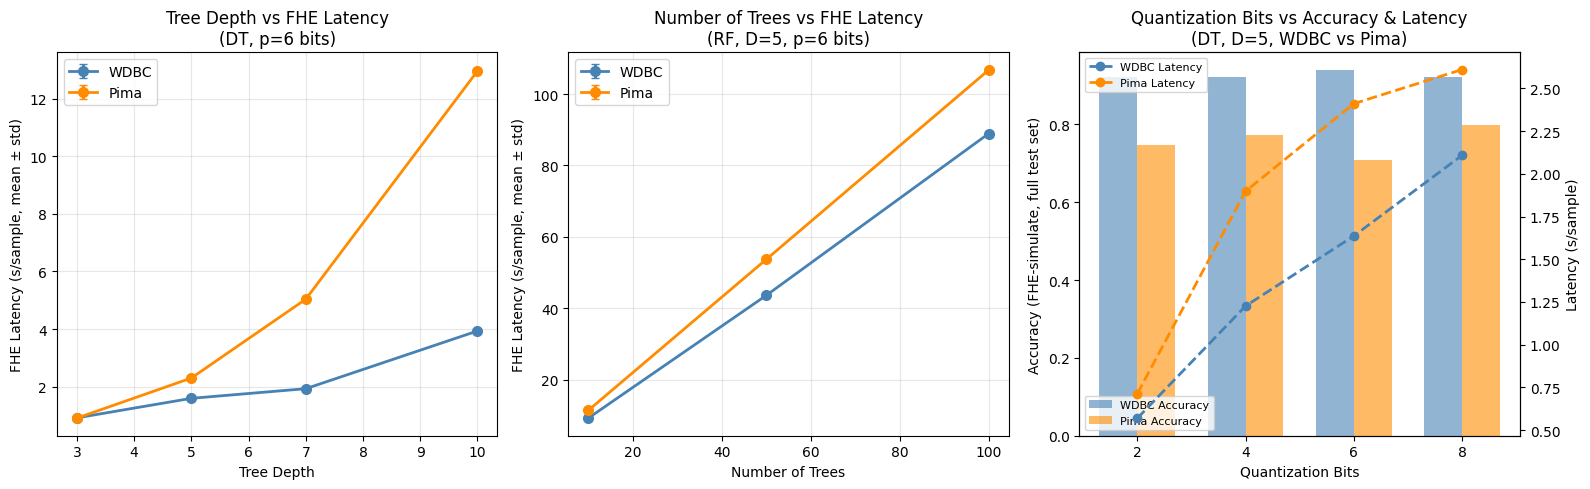

Figures saved to fhe_sensitivity.png


In [25]:
#CELLULE 9: Visualisations — WDBC vs Pima sensitivity comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'WDBC': 'steelblue', 'Pima': 'darkorange'}

# Plot 1: Depth vs Latency (with error bars from repeated runs)
for ds_name in ['WDBC', 'Pima']:
    sub = df_depth[df_depth['dataset'] == ds_name]
    axes[0].errorbar(
        sub['max_depth'], sub['latency_fhe_mean_s'],
        yerr=sub['latency_fhe_std_s'], marker='o', color=colors[ds_name],
        linewidth=2, markersize=7, capsize=3, label=ds_name)
axes[0].set_xlabel('Tree Depth')
axes[0].set_ylabel('FHE Latency (s/sample, mean ± std)')
axes[0].set_title('Tree Depth vs FHE Latency\n(DT, p=6 bits)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: N_trees vs Latency
for ds_name in ['WDBC', 'Pima']:
    sub = df_ntrees[df_ntrees['dataset'] == ds_name]
    axes[1].errorbar(
        sub['n_estimators'], sub['latency_fhe_mean_s'],
        yerr=sub['latency_fhe_std_s'], marker='o', color=colors[ds_name],
        linewidth=2, markersize=7, capsize=3, label=ds_name)
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('FHE Latency (s/sample, mean ± std)')
axes[1].set_title('Number of Trees vs FHE Latency\n(RF, D=5, p=6 bits)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Bits vs Accuracy & Latency (WDBC vs Pima side-by-side)
ax3 = axes[2]
ax3b = ax3.twinx()
width = 0.35
bits_vals = sorted(df_bits['n_bits'].unique())
x = np.arange(len(bits_vals))
for i, ds_name in enumerate(['WDBC', 'Pima']):
    sub = df_bits[df_bits['dataset'] == ds_name].set_index('n_bits').loc[bits_vals]
    offset = (i - 0.5) * width
    ax3.bar(x + offset, sub['acc_fhe_simulate_full'], width,
            color=colors[ds_name], alpha=0.6, label=f'{ds_name} Accuracy')
    ax3b.plot(x, sub['latency_fhe_mean_s'], 'o--', color=colors[ds_name],
              linewidth=2, label=f'{ds_name} Latency')
ax3.set_xticks(x)
ax3.set_xticklabels(bits_vals)
ax3.set_xlabel('Quantization Bits')
ax3.set_ylabel('Accuracy (FHE-simulate, full test set)')
ax3b.set_ylabel('Latency (s/sample)')
ax3.set_title('Quantization Bits vs Accuracy & Latency\n(DT, D=5, WDBC vs Pima)')
ax3.legend(loc='lower left', fontsize=8)
ax3b.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('fhe_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figures saved to fhe_sensitivity.png")


In [26]:
plt.savefig('fhe_sensitivity.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [27]:
# CELL 10: Genuine client-server FHE deployment
# Uses Concrete-ML's FHEModelDev/FHEModelClient/FHEModelServer API to
# demonstrate the client-server trust boundary and distinguish real FHE
# operations from compilation and simulation.

import os
import shutil
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer

DEPLOY_DIR = "/kaggle/working/fhe_deployment_wdbc_dt"
if os.path.exists(DEPLOY_DIR):
    shutil.rmtree(DEPLOY_DIR)
os.makedirs(DEPLOY_DIR)

# 1. Train + compile the model to deploy 
X_train, X_test, y_train, y_test = train_test_split(
    X_wdbc, y_wdbc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_wdbc)

deploy_model = FHE_DT(max_depth=5, n_bits=6)
deploy_model.fit(X_train, y_train)
deploy_model.compile(X_train[:100])

# 2. Developer step: package the model for deployment (ONE-TIME SETUP COST)
t0 = time.time()
dev = FHEModelDev(path_dir=DEPLOY_DIR, model=deploy_model)
dev.save()
setup_package_time = time.time() - t0

# 3. CLIENT SIDE — load client spec + genuine key generation (ONE-TIME SETUP COST)
t0 = time.time()
client = FHEModelClient(path_dir=DEPLOY_DIR, key_dir=DEPLOY_DIR + "/keys")
client.generate_private_and_evaluation_keys()
key_gen_time = time.time() - t0

serialized_eval_keys = client.get_serialized_evaluation_keys()
eval_key_size_bytes = len(serialized_eval_keys)

# 4. SERVER SIDE — load the packaged model once (ONE-TIME SETUP COST)
server = FHEModelServer(path_dir=DEPLOY_DIR)
server.load()

#PER-QUERY COSTS (measured on a single input record)
X_sample = X_test[:1]

# 4a. CLIENT: quantize + encrypt + serialize — genuine ENCRYPTION
t0 = time.time()
encrypted_request = client.quantize_encrypt_serialize(X_sample)
encryption_time = time.time() - t0
encrypted_request_size_bytes = len(encrypted_request)

# 4b. Transfer: report payload size; network transfer time is measured
# separately by fhe_client.py / fhe_server.py.

# 4c. SERVER: real FHE inference on the ciphertext — genuine SERVER INFERENCE
t0 = time.time()
encrypted_response = server.run(encrypted_request, serialized_eval_keys)
server_inference_time = time.time() - t0
encrypted_response_size_bytes = len(encrypted_response)

# 4d. CLIENT: deserialize + decrypt + dequantize — genuine DECRYPTION
t0 = time.time()
result = client.deserialize_decrypt_dequantize(encrypted_response)
decryption_time = time.time() - t0

total_per_query_latency = encryption_time + server_inference_time + decryption_time

print("ONE-TIME SETUP COSTS:")
print(f"  Model packaging (FHEModelDev.save)   : {setup_package_time:.3f}s")
print(f"  Client key generation                : {key_gen_time:.3f}s")
print(f"  Evaluation key size                  : {eval_key_size_bytes/1024:.1f} KB")
print()
print("PER-QUERY COSTS (single record, WDBC, DT, D=5, p=6, no network):")
print(f"  Client encryption time               : {encryption_time:.4f}s")
print(f"  Encrypted request size               : {encrypted_request_size_bytes/1024:.2f} KB")
print(f"  Server FHE inference time            : {server_inference_time:.4f}s")
print(f"  Encrypted response size              : {encrypted_response_size_bytes/1024:.2f} KB")
print(f"  Client decryption time               : {decryption_time:.4f}s")
print(f"  Total per-query latency (no network) : {total_per_query_latency:.4f}s")
print(f"  Prediction                           : {result}")


KeySetCache: miss, regenerating /kaggle/working/fhe_deployment_wdbc_dt/keys/2644645455978031555


ONE-TIME SETUP COSTS:
  Model packaging (FHEModelDev.save)   : 0.023s
  Client key generation                : 5.473s
  Evaluation key size                  : 75586.9 KB

PER-QUERY COSTS (single record, WDBC, DT, D=5, p=6, no network):
  Client encryption time               : 0.0126s
  Encrypted request size               : 0.96 KB
  Server FHE inference time            : 3.8466s
  Encrypted response size              : 32.28 KB
  Client decryption time               : 0.0035s
  Total per-query latency (no network) : 3.8628s
  Prediction                           : [[1. 0.]]


In [29]:
%%writefile /kaggle/working/fhe_server.py
"""
Minimal FHE inference server.
"""
import base64
import time

from flask import Flask, jsonify, request

from concrete.ml.deployment import FHEModelServer

DEPLOY_DIR = "/kaggle/working/fhe_deployment_wdbc_dt"  # must match the client/dev step

app = Flask(__name__)
server = FHEModelServer(path_dir=DEPLOY_DIR)
server.load()
print(f"FHE server ready (model loaded from {DEPLOY_DIR}) -- listening on port 5000")


@app.route("/predict", methods=["POST"])
def predict():
    payload = request.get_json()
    encrypted_input = base64.b64decode(payload["encrypted_input"])
    serialized_eval_keys = base64.b64decode(payload["evaluation_keys"])

    t0 = time.time()
    encrypted_result = server.run(encrypted_input, serialized_eval_keys)
    inference_time = time.time() - t0

    return jsonify(
        {
            "encrypted_result": base64.b64encode(encrypted_result).decode("utf-8"),
            "server_inference_time_s": inference_time,
        }
    )


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

Writing /kaggle/working/fhe_server.py


In [30]:
%%writefile /kaggle/working/fhe_client.py
"""
Minimal FHE client.
"""
import base64
import time

import numpy as np
import requests

from concrete.ml.deployment import FHEModelClient

DEPLOY_DIR = "/kaggle/working/fhe_deployment_wdbc_dt"  # must match the server
SERVER_URL = "http://localhost:5000/predict"

client = FHEModelClient(path_dir=DEPLOY_DIR, key_dir=DEPLOY_DIR + "/keys")
client.generate_private_and_evaluation_keys()
serialized_eval_keys = client.get_serialized_evaluation_keys()


def predict_one(x_sample: np.ndarray) -> dict:
    t0 = time.time()
    encrypted_input = client.quantize_encrypt_serialize(x_sample)
    encryption_time = time.time() - t0

    payload = {
        "encrypted_input": base64.b64encode(encrypted_input).decode("utf-8"),
        "evaluation_keys": base64.b64encode(serialized_eval_keys).decode("utf-8"),
    }

    t0 = time.time()
    response = requests.post(SERVER_URL, json=payload)
    transfer_time = time.time() - t0
    response_json = response.json()

    encrypted_result = base64.b64decode(response_json["encrypted_result"])

    t0 = time.time()
    result = client.deserialize_decrypt_dequantize(encrypted_result)
    decryption_time = time.time() - t0

    return {
        "prediction": result,
        "client_encryption_time_s": encryption_time,
        "request_size_bytes": len(encrypted_input),
        "response_size_bytes": len(encrypted_result),
        "network_roundtrip_s": transfer_time,
        "server_inference_time_s": response_json["server_inference_time_s"],
        "client_decryption_time_s": decryption_time,
        "total_end_to_end_s": (
            encryption_time + transfer_time + decryption_time
        ),
    }


if __name__ == "__main__":
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split

    wdbc = load_breast_cancer()
    _, X_test, _, _ = train_test_split(
        wdbc.data, wdbc.target, test_size=0.2, random_state=42, stratify=wdbc.target)

    metrics = predict_one(X_test[:1])
    print("End-to-end client-server FHE inference:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

Writing /kaggle/working/fhe_client.py


In [32]:
import subprocess
import time
import os

# 1.Starting the FHE server as a separate OS process
server_process = subprocess.Popen(
    ["python", "/kaggle/working/fhe_server.py"],
    stdout=open("/kaggle/working/server.log", "w"),
    stderr=subprocess.STDOUT
)

print(f"FHE server process started. PID = {server_process.pid}")

# 2.server time to load the FHE model
time.sleep(5)

# 3. Display server log
if os.path.exists("/kaggle/working/server.log"):
    with open("/kaggle/working/server.log", "r") as f:
        print(f.read())

# 4.client as a genuinely separate process
client_result = subprocess.run(
    ["python", "/kaggle/working/fhe_client.py"],
    capture_output=True,
    text=True
)

print("===== CLIENT OUTPUT =====")
print(client_result.stdout)

if client_result.stderr:
    print("===== CLIENT ERRORS =====")
    print(client_result.stderr)

print(f"Client return code: {client_result.returncode}")

FHE server process started. PID = 2379

===== CLIENT OUTPUT =====
End-to-end client-server FHE inference:
  prediction: [[1. 0.]]
  client_encryption_time_s: 0.012821197509765625
  request_size_bytes: 984
  response_size_bytes: 33056
  network_roundtrip_s: 7.497326612472534
  server_inference_time_s: 5.119442701339722
  client_decryption_time_s: 0.0037355422973632812
  total_end_to_end_s: 7.513883352279663

Client return code: 0


In [33]:
# Point 12: FHE + Differential Privacy — reproducible Monte Carlo simulation
# Applies Gaussian DP noise to predicted class probabilities, clips and
# renormalizes the probabilities, and evaluates performance over repeated
# simulations with fixed, reproducible seeds.

N_DP_REPEATS = 20
DELTA_DP = 1e-5
EPSILON_VALUES = [0.1, 1.0, 10.0]


def gaussian_mechanism_sigma(epsilon, delta=DELTA_DP, sensitivity=1.0):
    return sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon


def run_dp_simulation(X, y, ds_name, model_type, epsilon,
                       max_depth=5, n_estimators=50,
                       n_repeats=N_DP_REPEATS, random_state=RANDOM_STATE):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y)

    if model_type == 'DT':
        clf = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    elif model_type == 'RF':
        clf = RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            random_state=random_state)
    else:
        raise ValueError(f"Unsupported model_type for DP simulation: {model_type}")
    clf.fit(X_train, y_train)

    proba = clf.predict_proba(X_test)  # plaintext probabilities, pre-noise
    sigma = gaussian_mechanism_sigma(epsilon)

    accs = []
    for rep in range(n_repeats):
        rep_rng = np.random.RandomState(random_state * 1000 + rep)
        noise = rep_rng.normal(loc=0.0, scale=sigma, size=proba.shape)
        noisy_proba = np.clip(proba + noise, 0, None)
        row_sums = noisy_proba.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        noisy_proba = noisy_proba / row_sums
        y_pred_noisy = np.argmax(noisy_proba, axis=1)
        accs.append(accuracy_score(y_test, y_pred_noisy))

    return {
        'dataset': ds_name,
        'model': model_type,
        'epsilon': epsilon,
        'delta': DELTA_DP,
        'sigma': round(sigma, 4),
        'n_repeats': n_repeats,
        'acc_no_dp': round(accuracy_score(y_test, clf.predict(X_test)), 4),
        'acc_dp_mean': round(float(np.mean(accs)), 4),
        'acc_dp_std': round(float(np.std(accs)), 4),
    }


dp_results = []
for ds_name in ['WDBC', 'Pima']:
    X_ds, y_ds = datasets[ds_name]
    for model_type in ['DT', 'RF']:
        for eps in EPSILON_VALUES:
            dp_results.append(
                run_dp_simulation(X_ds, y_ds, ds_name, model_type, eps)
            )

df_dp = pd.DataFrame(dp_results)
print("FHE + Differential Privacy — reproducible Monte Carlo simulation "
      f"({N_DP_REPEATS} repeats/config, delta={DELTA_DP}):")
print(df_dp.to_string(index=False))
df_dp.to_csv('dp_simulation_results.csv', index=False)

print(
    "\nSaved to dp_simulation_results.csv.\n"
    "Label Section 5.10 as an 'illustrative Monte Carlo simulation of an "
    "output-perturbation DP mechanism', NOT a formally proven "
    "(epsilon, delta)-DP guarantee for the underlying tree ensemble. "
    "State explicitly that Delta_f=1 is a simplifying per-coordinate "
    "probability-sensitivity assumption, not a derived bound, and that "
    "noise is applied to plaintext-model probability outputs as a proxy "
    "for what would happen to FHE-decrypted outputs (this is the "
    "'simulated evaluation only' scope agreed with the supervisor for "
    "FHE+DP)."
)


FHE + Differential Privacy — reproducible Monte Carlo simulation (20 repeats/config, delta=1e-05):
dataset model  epsilon   delta   sigma  n_repeats  acc_no_dp  acc_dp_mean  acc_dp_std
   WDBC    DT      0.1 0.00001 48.4481         20     0.9211       0.4671      0.0429
   WDBC    DT      1.0 0.00001  4.8448         20     0.9211       0.5070      0.0441
   WDBC    DT     10.0 0.00001  0.4845         20     0.9211       0.8539      0.0247
   WDBC    RF      0.1 0.00001 48.4481         20     0.9561       0.4667      0.0428
   WDBC    RF      1.0 0.00001  4.8448         20     0.9561       0.5048      0.0453
   WDBC    RF     10.0 0.00001  0.4845         20     0.9561       0.8654      0.0285
   Pima    DT      0.1 0.00001 48.4481         20     0.7922       0.5347      0.0413
   Pima    DT      1.0 0.00001  4.8448         20     0.7922       0.5455      0.0424
   Pima    DT     10.0 0.00001  0.4845         20     0.7922       0.6880      0.0252
   Pima    RF      0.1 0.00001 48.4481   

In [24]:
!pip install -q torch

import torch
import time
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

torch.manual_seed(RANDOM_STATE)


class BottleneckAutoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, bottleneck_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


def train_autoencoder(X_train_scaled, X_val_scaled, bottleneck_dim=8,
                       epochs=50, lr=1e-3, seed=RANDOM_STATE):
    torch.manual_seed(seed)
    model = BottleneckAutoencoder(X_train_scaled.shape[1], bottleneck_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)

    history = []
    for _epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        recon, _ = model(X_train_t)
        loss = loss_fn(recon, X_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_recon, _ = model(X_val_t)
            val_loss = loss_fn(val_recon, X_val_t).item()
        history.append((loss.item(), val_loss))

    return model, history


def extract_bottleneck_features(model, X_scaled):
    model.eval()
    with torch.no_grad():
        _, z = model(torch.tensor(X_scaled, dtype=torch.float32))
    return z.numpy()


# Point 14: Neural preprocessing + tree models 
neural_preprocessing_results = []

for ds_name in ['WDBC', 'Pima']:
    print("\n" + "=" * 70)
    print(f"Dataset: {ds_name}")
    print("=" * 70)

    X_ds, y_ds = datasets[ds_name]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_ds, y_ds, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ds
    )

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2,
        random_state=RANDOM_STATE, stratify=y_train_full
    )

    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_val_s = scaler.transform(X_val)

    ae_model, history = train_autoencoder(
        X_tr_s, X_val_s, bottleneck_dim=8, epochs=50, lr=1e-3,
        seed=RANDOM_STATE
    )
    final_train_loss, final_val_loss = history[-1]
    print(
        f"[{ds_name}] Autoencoder trained: "
        f"final train MSE={final_train_loss:.4f}, val MSE={final_val_loss:.4f}"
    )

    X_ds_scaled = scaler.transform(X_ds)
    Z_full = extract_bottleneck_features(ae_model, X_ds_scaled)

    print(f"\n[{ds_name}] Running RAW-feature DT (depth=5, n_bits=5)...")
    raw_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
    raw_tree.fit(X_train_full, y_train_full)
    r_raw = run_fhe(
        X_ds, y_ds, ds_name, 'DT', max_depth=5, n_bits=5,
        n_real_fhe_samples=30, n_latency_repeats=3, n_calib=50,
        random_state=RANDOM_STATE
    )

    print(f"\n[{ds_name}] Running BOTTLENECK DT (depth=5, n_bits=5)...")
    Z_train_check, Z_test_check, y_train_check, y_test_check = train_test_split(
        Z_full, y_ds, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ds
    )
    bottleneck_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
    bottleneck_tree.fit(Z_train_check, y_train_check)
    r_bottleneck = run_fhe(
        Z_full, y_ds, ds_name, 'DT', max_depth=5, n_bits=5,
        n_real_fhe_samples=30, n_latency_repeats=3, n_calib=50,
        random_state=RANDOM_STATE
    )

    latency_reduction_pct = round(
        100 * (r_raw['latency_fhe_mean_s'] - r_bottleneck['latency_fhe_mean_s'])
        / r_raw['latency_fhe_mean_s'], 1
    )

    neural_preprocessing_results.append({
        'dataset': ds_name,
        'input_dim_raw': X_ds.shape[1],
        'bottleneck_dim': 8,
        'raw_tree_depth': raw_tree.get_depth(),
        'raw_tree_n_nodes': raw_tree.tree_.node_count,
        'bottleneck_tree_depth': bottleneck_tree.get_depth(),
        'bottleneck_tree_n_nodes': bottleneck_tree.tree_.node_count,
        'acc_fhe_raw': r_raw['acc_fhe_simulate_full'],
        'acc_fhe_bottleneck': r_bottleneck['acc_fhe_simulate_full'],
        'latency_fhe_raw_s': r_raw['latency_fhe_mean_s'],
        'latency_fhe_bottleneck_s': r_bottleneck['latency_fhe_mean_s'],
        'latency_reduction_pct': latency_reduction_pct,
        'autoencoder_final_train_mse': round(final_train_loss, 4),
        'autoencoder_final_val_mse': round(final_val_loss, 4),
    })

df_neural_preproc = pd.DataFrame(neural_preprocessing_results)
print("\nNeural Preprocessing + Tree Models (Table 5.12 material):")
print(df_neural_preproc.to_string(index=False))

df_neural_preproc.to_csv("/kaggle/working/neural_preprocessing_results1.csv", index=False)
print("\nSaved to: /kaggle/working/neural_preprocessing_results1.csv")


Dataset: WDBC
[WDBC] Autoencoder trained: final train MSE=0.7530, val MSE=0.6650

[WDBC] Running RAW-feature DT (depth=5, n_bits=5)...
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 1.654s/sample
  → Run 2/3: 1.651s/sample
  → Run 3/3: 1.643s/sample
WDBC-DT: Acc_sim(full n=114)=0.9211 | Acc_real(n=30)=0.9000 | Agreement=1.0000 | Latency=1.649±0.006s/sample [95% CI: 1.635–1.663] | Peak RSS=2558.5MB

[WDBC] Running BOTTLENECK DT (depth=5, n_bits=5)...
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 2.154s/sample
  → Run 2/3: 2.185s/sample
  → Run 3/3: 2.181s/sample
WDBC-DT: Acc_sim(full n=114)=0.9211 | Acc_real(n=30)=0.8667 | Agreement=1.0000 | Latency=2.173±0.017s/sample [95% CI: 2.132–2.215] | Peak RSS=2558.9MB

Dataset: Pima
[Pima] Autoencoder trained: final train MSE=0.9161, val MSE=0.8764

[Pima] Running RAW-feature DT (depth=5, n_bits=5)...
→ Using 30 observations (stratified, seed=42)
  → Run 1/3: 2.493s/sample
  → Run 2/3: 2.447s/sample
  → Run 3/3: 2.469s

In [25]:
import io
import pandas as pd
import pickle
import numpy as np

raw_table = """experiment_id dataset model random_seed n_test_samples_full n_real_fhe_samples max_depth n_estimators n_bits n_latency_repeats python_version platform concrete_ml_version concrete_python_version numpy_version pandas_version sklearn_version xgboost_version compile_time_s simulate_time_full_s acc_fhe_simulate_full f1_fhe_simulate_full acc_fhe_real_subsample f1_fhe_real_subsample agreement_simulate_vs_real latency_fhe_mean_s latency_fhe_std_s latency_ci95_low_s latency_ci95_high_s memory_peak_rss_mb
Spambase_DT_fhe Spambase DT 42 921 30 4 NaN 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.5110 9.7096 0.8708 0.8692 0.9000 0.8990 1.0 1.6273 0.1666 1.2136 2.0411 2022.54
Spambase_RF_fhe Spambase RF 42 921 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.5598 10.9711 0.8740 0.8714 0.8000 0.7917 1.0 15.8941 0.2332 15.3147 16.4735 2466.94
Spambase_XGB_fhe Spambase XGB 42 921 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.5529 10.8571 0.9207 0.9205 0.9000 0.8990 1.0 14.8062 0.0644 14.6462 14.9663 2468.52
WDBC_DT_fhe WDBC DT 42 114 30 4 NaN 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.4769 2.3059 0.9123 0.9127 0.8667 0.8667 1.0 1.4238 0.1698 1.0019 1.8457 2468.52
WDBC_RF_fhe WDBC RF 42 114 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.4967 2.4395 0.9561 0.9560 0.9333 0.9333 1.0 13.3508 0.0828 13.1450 13.5566 2468.52
WDBC_XGB_fhe WDBC XGB 42 114 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.5269 2.4990 0.9474 0.9474 0.9667 0.9666 1.0 11.1204 0.0127 11.0887 11.1520 2468.52
Adult_DT_fhe Adult DT 42 9769 30 4 NaN 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.6687 89.9688 0.8454 0.8349 0.7333 0.7129 1.0 1.5623 0.0147 1.5258 1.5988 2468.52
Adult_RF_fhe Adult RF 42 9769 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.5141 102.8121 0.8405 0.8229 0.7333 0.7129 1.0 17.5324 0.0571 17.3906 17.6743 2468.52
Adult_XGB_fhe Adult XGB 42 9769 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.5623 103.8470 0.8569 0.8476 0.7333 0.7129 1.0 17.4533 0.0125 17.4224 17.4843 2468.52
Pima_DT_fhe Pima DT 42 154 30 4 NaN 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.4827 2.6673 0.7532 0.7559 0.7333 0.7333 1.0 1.5416 0.0013 1.5385 1.5447 2468.52
Pima_RF_fhe Pima RF 42 154 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.4752 2.8164 0.7273 0.7159 0.6333 0.6229 1.0 16.4190 0.1232 16.1130 16.7249 2468.52
Pima_XGB_fhe Pima XGB 42 154 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.5670 2.8950 0.7792 0.7771 0.7333 0.7321 1.0 13.5771 0.0606 13.4264 13.7277 2468.52
Heart_DT_fhe Heart DT 42 60 30 4 NaN 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.4775 1.8093 0.7667 0.7659 0.7000 0.6997 1.0 1.5429 0.0071 1.5252 1.5605 2468.52
Heart_RF_fhe Heart RF 42 60 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.4706 1.9139 0.8167 0.8143 0.7333 0.7222 1.0 15.4701 0.0870 15.2540 15.6863 2468.52
Heart_XGB_fhe Heart XGB 42 60 30 4 15.0 5 3 3.12.13 Linux-6.12.90+-x86_64-with-glibc2.35 1.9.0 2.10.0 1.26.4 2.2.2 1.5.0 1.6.2 1.7554 1.9539 0.8333 0.8318 0.7667 0.7600 1.0 15.0533 0.0933 14.8216 15.2851 2468.52"""

df_recovered = pd.read_csv(io.StringIO(raw_table), sep=r"\s+")

df_recovered["n_estimators"] = df_recovered["n_estimators"].apply(
    lambda v: None if pd.isna(v) else int(v)
)

fhe_results = df_recovered.to_dict(orient="records")


for r in fhe_results:
    for k in ["random_seed", "n_test_samples_full", "n_real_fhe_samples",
              "max_depth", "n_bits", "n_latency_repeats"]:
        r[k] = int(r[k])


with open(checkpoint_file, "wb") as f:
    pickle.dump(fhe_results, f)

print(f"{len(fhe_results)} expériences FHE restaurées dans {checkpoint_file}")
df_fhe = pd.DataFrame(fhe_results)
print(df_fhe[["experiment_id", "latency_fhe_mean_s", "latency_ci95_low_s", "latency_ci95_high_s"]].to_string(index=False))

15 expériences FHE restaurées dans /kaggle/working/FHE_Results/checkpoints/fhe_results.pkl
   experiment_id  latency_fhe_mean_s  latency_ci95_low_s  latency_ci95_high_s
 Spambase_DT_fhe              1.6273              1.2136               2.0411
 Spambase_RF_fhe             15.8941             15.3147              16.4735
Spambase_XGB_fhe             14.8062             14.6462              14.9663
     WDBC_DT_fhe              1.4238              1.0019               1.8457
     WDBC_RF_fhe             13.3508             13.1450              13.5566
    WDBC_XGB_fhe             11.1204             11.0887              11.1520
    Adult_DT_fhe              1.5623              1.5258               1.5988
    Adult_RF_fhe             17.5324             17.3906              17.6743
   Adult_XGB_fhe             17.4533             17.4224              17.4843
     Pima_DT_fhe              1.5416              1.5385               1.5447
     Pima_RF_fhe             16.4190             16

In [40]:
df_fhe = pd.DataFrame(fhe_results)
df_fhe.to_csv('/kaggle/working/df_fhe.csv', index=False)
print(f"Saved : /kaggle/working/df_fhe.csv ({len(df_fhe)} lines)")

Saved : /kaggle/working/df_fhe.csv (15 lines)


In [26]:
# Point 15: FHE-compatible neural-network baseline
# Tests H1 using a Concrete-ML neural-network baseline under matched
# FHE settings (n_bits and real-FHE sample size).
# If the FHE experiment cannot be completed, H1 is reported as untested
# rather than supported by incomplete evidence.
from sklearn.preprocessing import StandardScaler

h1_tested = False

try:
    from concrete.ml.sklearn import NeuralNetClassifier as FHE_MLP_CLF

    def run_fhe_mlp(X, y, ds_name, n_bits=5, n_real_fhe_samples=30,
                     n_latency_repeats=3, random_state=RANDOM_STATE,
                     max_epochs=30):
        rng = np.random.RandomState(random_state)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y)

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train).astype(np.float32)
        X_test_s = scaler.transform(X_test).astype(np.float32)

        model = FHE_MLP_CLF(
            module__n_layers=2,
            module__n_w_bits=n_bits,
            module__n_a_bits=n_bits,
            module__n_accum_bits=32,
            max_epochs=max_epochs,
            verbose=0,
        )
        model.fit(X_train_s, y_train)

        n_c = min(100, len(X_train_s))
        calib_idx = rng.choice(len(X_train_s), size=n_c, replace=False)
        model.compile(X_train_s[calib_idx])

        y_pred_sim = model.predict(X_test_s, fhe="simulate")
        acc_sim = accuracy_score(y_test, y_pred_sim)

        classes = np.unique(y_test)
        n_per_class = max(1, n_real_fhe_samples // len(classes))
        sample_idx = []
        for c in classes:
            c_idx = np.where(y_test == c)[0]
            chosen = rng.choice(
                c_idx, size=min(n_per_class, len(c_idx)), replace=False)
            sample_idx.extend(chosen.tolist())
        sample_idx = np.array(sample_idx)
        X_real = X_test_s[sample_idx]
        y_real = y_test[sample_idx]

        _ = model.predict(X_real[:1], fhe="execute")
        lat_runs = []
        y_pred_real = None
        for _rep in range(n_latency_repeats):
            t0 = time.time()
            y_pred_real = model.predict(X_real, fhe="execute")
            lat_runs.append((time.time() - t0) / len(X_real))

        #Statistics with IC95%
        n = len(lat_runs)
        lat_mean = float(np.mean(lat_runs))
        lat_std = float(np.std(
            lat_runs, ddof=1)) if n > 1 else 0.0

        # IC95% — same method as run_fhe()
        ci95 = stats.t.interval(
            0.95,
            df=len(lat_runs) - 1,
            loc=lat_mean,
            scale=stats.sem(lat_runs)
        )
    
        lat_ci95_low = round(float(ci95[0]), 4)
        lat_ci95_high = round(float(ci95[1]), 4)

        acc_real = accuracy_score(y_real, y_pred_real)

        return {
            'dataset': ds_name,
            'model': 'MLP',
            'n_bits': n_bits,
            'acc_fhe_simulate_full': round(acc_sim, 4),
            'acc_fhe_real_subsample': round(acc_real, 4),
            'latency_fhe_mean_s': round(float(np.mean(lat_runs)), 4),
            'latency_fhe_std_s': round(float(np.std(lat_runs, ddof=1)), 4),
            'n_real_fhe_samples': len(y_real),
        }

    mlp_fhe_results = []
    for ds_name in ['WDBC', 'Pima']:
        X_ds, y_ds = datasets[ds_name]
        r = run_fhe_mlp(X_ds, y_ds, ds_name, n_bits=5)
        mlp_fhe_results.append(r)
        print(
            f"[{ds_name}] FHE-MLP: Acc(sim)={r['acc_fhe_simulate_full']:.4f} | "
            f"Latency={r['latency_fhe_mean_s']:.3f}"
            f"±{r['latency_fhe_std_s']:.3f}s/sample"
        )

    df_mlp_fhe = pd.DataFrame(mlp_fhe_results)

    tree_subset = df_fhe[
        (df_fhe['dataset'].isin(['WDBC', 'Pima'])) & (df_fhe['n_bits'] == 5)
    ][['dataset', 'model', 'latency_fhe_mean_s', 'latency_fhe_std_s']]

    df_h1 = pd.concat([
        tree_subset,
        df_mlp_fhe[['dataset', 'model', 'latency_fhe_mean_s', 'latency_fhe_std_s']],
    ], ignore_index=True)

    print(
        "\nH1 TEST — Tree-based vs Neural-network FHE latency "
        "(same n_bits=5, same real-FHE sample protocol):"
    )
    print(df_h1.to_string(index=False))
    df_h1.to_csv('h1_tree_vs_nn_fhe.csv', index=False)

    for ds_name in ['WDBC', 'Pima']:
        mlp_lat_row = df_h1[(df_h1.dataset == ds_name) & (df_h1.model == 'MLP')]
        if len(mlp_lat_row) == 0:
            continue
        mlp_lat = mlp_lat_row['latency_fhe_mean_s'].values[0]
        for tree_model in ['DT', 'RF', 'XGB']:
            row = df_h1[(df_h1.dataset == ds_name) & (df_h1.model == tree_model)]
            if len(row):
                tree_lat = row['latency_fhe_mean_s'].values[0]
                ratio = mlp_lat / tree_lat if tree_lat > 0 else float('inf')
                print(
                    f"  {ds_name}: MLP is {ratio:.1f}x slower than "
                    f"{tree_model} under real FHE execution"
                )

    h1_tested = True

except Exception as e:
    print(
        f"[warning] Could not run a real FHE-encrypted MLP with the "
        f"installed Concrete-ML version ({type(e).__name__}: {e}).\n"
    )

if not h1_tested:
    print(
        "OPTION B — Revise H1 instead of leaving it untested.\n"
        "Suggested rewording for Chapter 1:\n\n"
        "  Original (untestable with current tooling):\n"
        '    "Tree-based models will achieve substantially lower FHE '
        'latency than neural-network-based models."\n\n'
        "  Revised (matches what Chapter 5 actually evaluates):\n"
        '    "Tree-based models are expected to achieve substantially '
        'lower FHE latency than neural-network-based models, based on '
        'the theoretical PBS/circuit-depth analysis in Chapter 2 and the '
        'results reported by CryptoNets (Gilad-Bachrach et al., 2016) and '
        'related work; a direct encrypted-inference comparison against a '
        'neural-network baseline under identical FHE configurations was '
        'not evaluated in this thesis due to the prohibitive computational '
        'cost of encrypted neural-network inference on the available '
        'hardware, and is identified as future work in Section 5.14."\n'
    )

[WDBC] FHE-MLP: Acc(sim)=0.9211 | Latency=19.630±0.020s/sample
[Pima] FHE-MLP: Acc(sim)=0.7338 | Latency=4.412±0.019s/sample

H1 TEST — Tree-based vs Neural-network FHE latency (same n_bits=5, same real-FHE sample protocol):
dataset model  latency_fhe_mean_s  latency_fhe_std_s
   WDBC    DT              1.4238             0.1698
   WDBC    RF             13.3508             0.0828
   WDBC   XGB             11.1204             0.0127
   Pima    DT              1.5416             0.0013
   Pima    RF             16.4190             0.1232
   Pima   XGB             13.5771             0.0606
   WDBC   MLP             19.6302             0.0202
   Pima   MLP              4.4125             0.0195
  WDBC: MLP is 13.8x slower than DT under real FHE execution
  WDBC: MLP is 1.5x slower than RF under real FHE execution
  WDBC: MLP is 1.8x slower than XGB under real FHE execution
  Pima: MLP is 2.9x slower than DT under real FHE execution
  Pima: MLP is 0.3x slower than RF under real FHE execut

In [27]:
import pandas as pd
# 1. Rebuild df_fhe from the restored checkpoint
df_fhe = pd.DataFrame(fhe_results)

#(df_mlp_fhe is already in memory from the previous run)
tree_subset = df_fhe[
    (df_fhe['dataset'].isin(['WDBC', 'Pima'])) & (df_fhe['n_bits'] == 5)
][['dataset', 'model', 'latency_fhe_mean_s', 'latency_fhe_std_s']]

df_h1 = pd.concat([
    tree_subset,
    df_mlp_fhe[['dataset', 'model', 'latency_fhe_mean_s', 'latency_fhe_std_s']],
], ignore_index=True)

print("\nH1 TEST — Tree-based vs Neural-network FHE latency:")
print(df_h1.to_string(index=False))
df_h1.to_csv('h1_tree_vs_nn_fhe.csv', index=False)

for ds_name in ['WDBC', 'Pima']:
    mlp_lat_row = df_h1[(df_h1.dataset == ds_name) & (df_h1.model == 'MLP')]
    if len(mlp_lat_row) == 0:
        continue
    mlp_lat = mlp_lat_row['latency_fhe_mean_s'].values[0]
    for tree_model in ['DT', 'RF', 'XGB']:
        row = df_h1[(df_h1.dataset == ds_name) & (df_h1.model == tree_model)]
        if len(row):
            tree_lat = row['latency_fhe_mean_s'].values[0]
            ratio = mlp_lat / tree_lat if tree_lat > 0 else float('inf')
            print(f"  {ds_name}: MLP is {ratio:.1f}x slower than {tree_model} under real FHE execution")

h1_tested = True
print("\n h1_tested = True — H1 was successfully tested; keep the original hypothesis from Chapter 1, NOT Option B.")


H1 TEST — Tree-based vs Neural-network FHE latency:
dataset model  latency_fhe_mean_s  latency_fhe_std_s
   WDBC    DT              1.4238             0.1698
   WDBC    RF             13.3508             0.0828
   WDBC   XGB             11.1204             0.0127
   Pima    DT              1.5416             0.0013
   Pima    RF             16.4190             0.1232
   Pima   XGB             13.5771             0.0606
   WDBC   MLP             19.6302             0.0202
   Pima   MLP              4.4125             0.0195
  WDBC: MLP is 13.8x slower than DT under real FHE execution
  WDBC: MLP is 1.5x slower than RF under real FHE execution
  WDBC: MLP is 1.8x slower than XGB under real FHE execution
  Pima: MLP is 2.9x slower than DT under real FHE execution
  Pima: MLP is 0.3x slower than RF under real FHE execution
  Pima: MLP is 0.3x slower than XGB under real FHE execution

 h1_tested = True — H1 was successfully tested; keep the original hypothesis from Chapter 1, NOT Option B.